<a href="https://colab.research.google.com/github/WiebkePetersen/GermevalFlausch/blob/main/Lehre_flausch_task1_train_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# auf Google Colab muss numpy Version runtergesetzt werden, und anschließend Sitzung neu gestartet werden,
# damit Task 1 läuft. Sonst kommt es im Training zu Fehlerabbrüchen
#!pip install numpy==1.26.4


In [1]:
!pip install transformers

Alle Abbildungen aus Tunstall et. al.



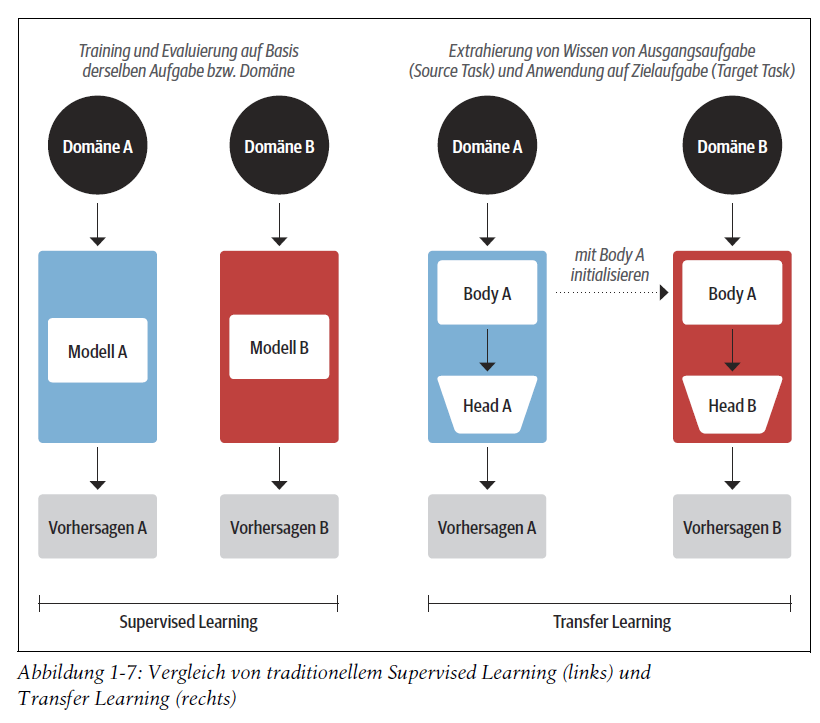

Letzte Sitzung: Transformer mit Classification Head:


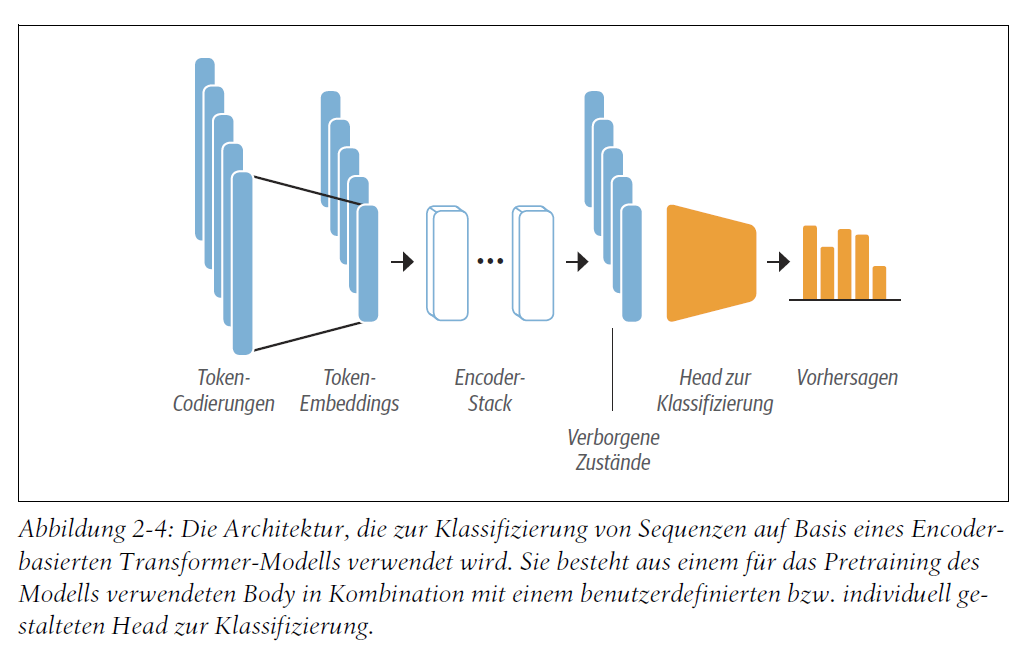

Feature-basierter Ansatz: Training eines Klassifizierers auf dem letzten Hidden State eines pretrained Transformers

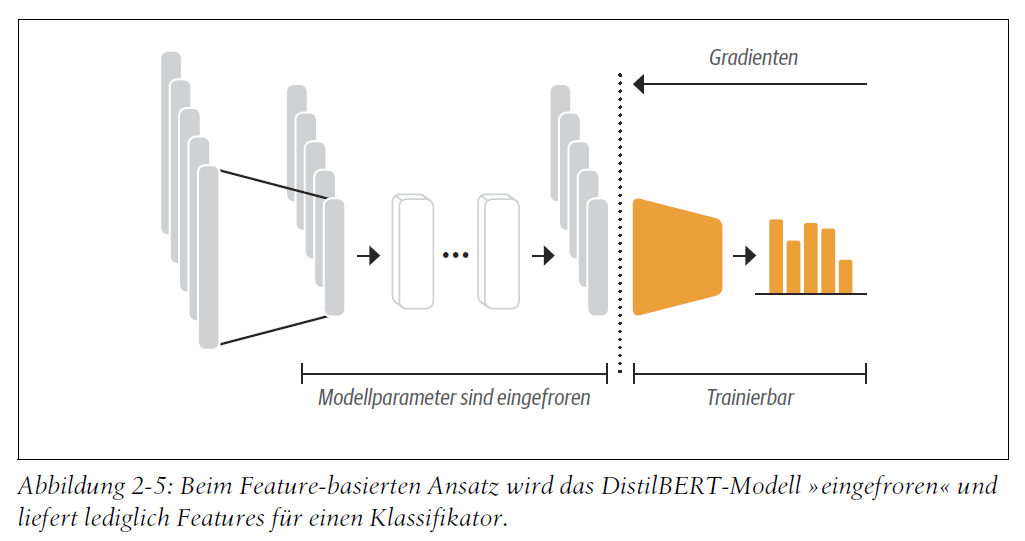

Heute Finetuning:

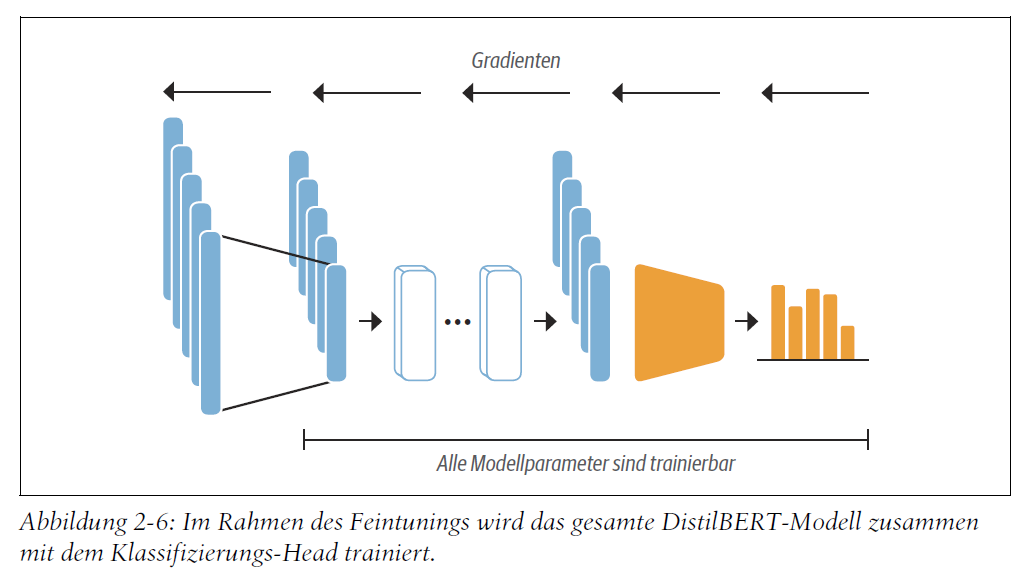

# Flausch Detection - Task 1: binary comment classification

## Flausch Detection: Subtask 1: binary comment classification -- train BERT model

### Task description and data input

Task 1 of GermEval@Konvens Shared task [Candy speech detection (Flausch-Erkennung)](https://yuliacl.github.io/GermEval2025-Flausch-Erkennung/)

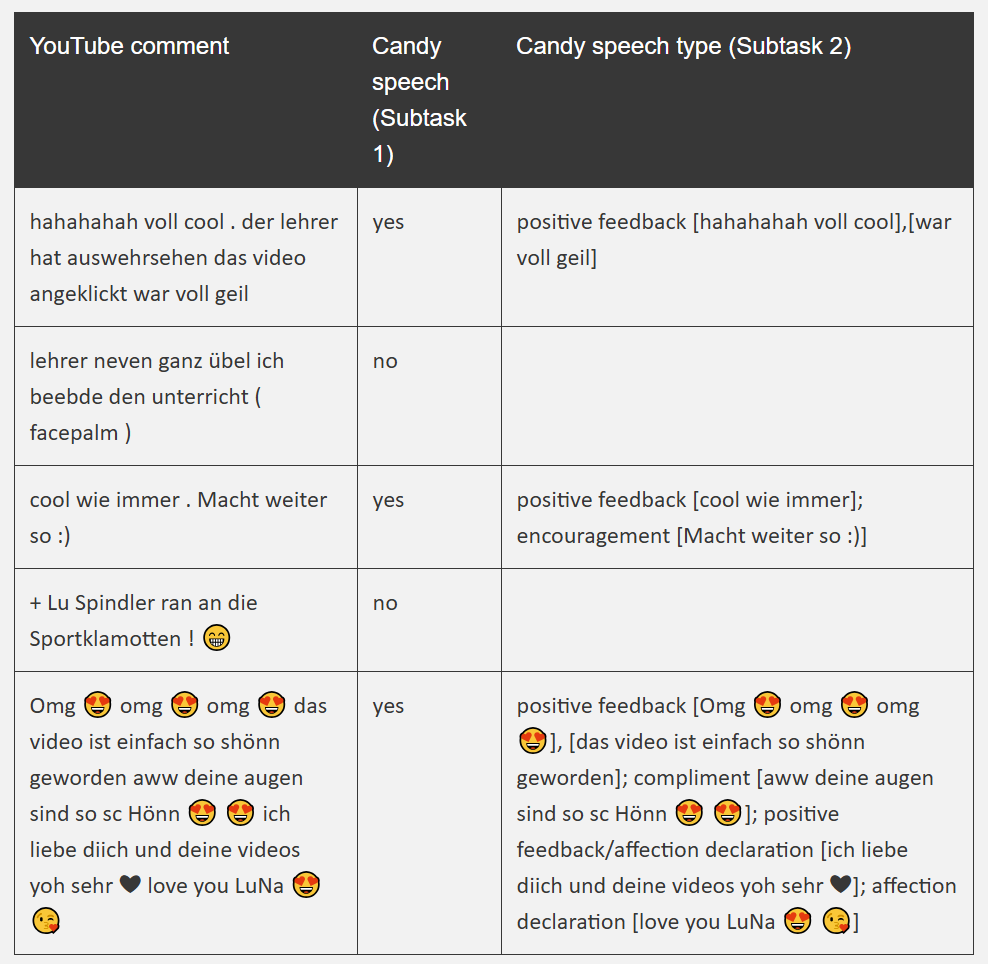


In [2]:
import numpy as np
import pandas as pd

# 1. Base path pointing to the raw GitHub user content
base_path = (
    "https://raw.githubusercontent.com/WiebkePetersen/GermevalFlausch/main/Input/Data/"
)

# 2. Load Task 1 data (Inside the 'train' folder)
# Added typ='frame' to ensure pandas parses it as a DataFrame cleanly
data = pd.read_json(base_path + "train/train_task1.json", typ="frame")
data = data[
    [
        "document",
        "comment_id",
        "comment",
        "flausch",
        "spans",
        "span_pairs",
        "types",
        "id",
    ]
].copy()

# 3. Load Task 2 data
data2 = pd.read_json(base_path + "train/train_task2.json", typ="frame")
data2 = data2[
    [
        "document",
        "comment_id",
        "type",
        "start",
        "end",
        "comment",
        "flausch",
        "span",
        "id",
    ]
].copy()

In [3]:
data.head(5)

,document,comment_id,comment,flausch,spans,span_pairs,types,id
20299,NDY-208,1989,würde ich auch gerne wenn meine Freunde sie ni...,no,[],[],[],NDY-208_1989
26830,NDY-208,8520,"Ich bin neun und bin ein Mädchen , brauche abe...",no,[],[],[],NDY-208_8520
19666,NDY-208,1356,7 Minuten,no,[],[],[],NDY-208_1356
25612,NDY-208,7302,10 - 20 Minuten 😂,no,[],[],[],NDY-208_7302
33492,NDY-250,868,wie wunderschön du in diesem video bist 3,yes,[wie wunderschön du in diesem video bist 3],"[[0, 41]]",[compliment],NDY-250_868


In [4]:
data2.head(5)

,document,comment_id,type,start,end,comment,flausch,span,id
0,NDY-003,1,compliment,0,11,Respekt : o zu mir passt das heut vollkommen :...,yes,Respekt : o,NDY-003_1
1,NDY-003,1,compliment,48,71,Respekt : o zu mir passt das heut vollkommen :...,yes,Aber Respekt an euch ;),NDY-003_1
2,NDY-003,2,positive feedback,0,12,haha geil :D aber ich hab mich am anfang etwas...,yes,haha geil :D,NDY-003_2
3,NDY-003,3,positive feedback,0,31,würd gern mit euch tanzen * - * haha,yes,würd gern mit euch tanzen * - *,NDY-003_3
4,NDY-003,4,positive feedback,0,23,Einfach nur wieder geil ... ich mag eure texte...,yes,Einfach nur wieder geil,NDY-003_4


### Make datasets and tokenize

In [5]:
import pandas as pd
from datasets import Dataset, DatasetDict


id2label = {0: 'no', 1: 'yes'}
label2id = {'no': 0, 'yes': 1}
data['labels'] = data['flausch'].map(label2id)

# Convert to Hugging Face Dataset

dataset = Dataset.from_pandas(data)



In [6]:
dataset

Dataset({
    features: ['document', 'comment_id', 'comment', 'flausch', 'spans', 'span_pairs', 'types', 'id', 'labels', '__index_level_0__'],
    num_rows: 33351
})

In [7]:
import torch
from transformers import AutoTokenizer

#checkpoint = "FacebookAI/roberta-large"
#checkpoint = "deepset/gbert-large"
checkpoint = "distilbert/distilbert-base-german-cased"

column = "comment" #"spelling_corrected" # "translated" #

model_name =   checkpoint.split("/")[-1] + "_" + column + "_lehre"

tokenizer = AutoTokenizer.from_pretrained(checkpoint)


def tokenize_function(examples):
    inputs = [str(x) for x in examples[column]]
    # Der Tokenizer gibt hier Listen von Listen zurück (für den Batch)
    tokenized_inputs = tokenizer(inputs, truncation=True, max_length=512)
    return tokenized_inputs

# remove columns not needed for tokenization



# Tokenize dataset
tokenized_dataset = dataset.map(tokenize_function, batched=True)

keep_cols = ['labels', 'input_ids', 'attention_mask']

# Setze das Format auf PyTorch-Tensoren
tokenized_dataset.set_format("torch")
tokenized_dataset = tokenized_dataset.remove_columns([col for col in tokenized_dataset.column_names if col not in keep_cols])


config.json:   0%|          | 0.00/464 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/240k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/479k [00:00<?, ?B/s]

Map:   0%|          | 0/33351 [00:00<?, ? examples/s]

In [8]:
tokenized_dataset

Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 33351
})

In [9]:
tokenized_dataset["attention_mask"][0]

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [10]:
tokenized_dataset["input_ids"][0]

tensor([  102,  1618,   383,   313,  4213,   684,  1717,  5509,   307,   255,
        11505,  2827,   103])

In [11]:
tokenizer.decode(tokenized_dataset["input_ids"][0])

'[CLS] würde ich auch gerne wenn meine Freunde sie nicht schauen würden [SEP]'

In [12]:
# data consists of 90% of the data
# 85% of this data is used as train data and 15% as dev data
train_val_split = tokenized_dataset.train_test_split(test_size=0.15, seed=42)
train_dataset = train_val_split["train"]
dev_dataset = train_val_split["test"]


# Create a DatasetDict
dataset_dict = DatasetDict({
    'train': train_dataset,
    'dev': dev_dataset,
})

dataset_dict

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 28348
    })
    dev: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 5003
    })
})

### Define model and trainer and train

In [42]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
import numpy as np

# load model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

# Data Collator
# Padd alle Batches auf die längste Sequenz im Batch
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


# Define metric function
from sklearn.metrics import accuracy_score, f1_score
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-german-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [43]:

# Define TrainingArguments
from transformers import TrainingArguments, Trainer
import os

finetuned_model = "flausch_task1_classification_" + checkpoint.split("/")[-1] + "_lehre"


training_args = TrainingArguments(
    output_dir=  finetuned_model,
    learning_rate=2e-5,
    per_device_train_batch_size=16, # Reduziere um OOM zu vermeiden
    per_device_eval_batch_size=16,  # Reduziere um OOM zu vermeiden
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="steps",
    save_strategy="no",
    load_best_model_at_end=False,
    logging_steps=750, # Alle XX Schritte loggen
    fp16=True, # Für schnellere und speichereffizientere Berechnung auf GPU
    gradient_checkpointing=True, # Hilft gegen OOM bei großen Modellen, macht Training langsamer
#    save_total_limit=1, # Nur das beste Modell speichern
    report_to="none", # Wichtig: W&B und andere Logger deaktivieren, falls nicht gewünscht
    push_to_hub=False, # Zuerst trainieren, dann manuell pushen
    metric_for_best_model="eval_f1", # competition ranking metric
    greater_is_better=True, # Setze auf False, wenn du Loss minimieren willst
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["dev"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)




In [44]:
# Trick um die nervige torchvision Fehlermeldung zu vermeiden.
import sys

# Trick datasets into thinking torchvision is not available to bypass the VideoReader bug
sys.modules.pop("torchvision", None)

In [45]:
print("\nPredictions on dev set before training.")

predictions_output = trainer.predict(test_dataset=dataset_dict["dev"])
print(predictions_output.metrics)


Predictions on dev set before training.


{'test_loss': 0.6800661087036133, 'test_model_preparation_time': 0.0029, 'test_accuracy': 0.6308215070957426, 'test_f1': 0.5804412305707318, 'test_runtime': 6.6818, 'test_samples_per_second': 748.747, 'test_steps_per_second': 46.843}


In [46]:
trainer.train()

print("\nTraining abgeschlossen.")


Step,Training Loss,Validation Loss,Accuracy,F1
750,0.297752,0.259781,0.903258,0.899530
1500,0.237087,0.221300,0.923246,0.921573
2250,0.191310,0.219772,0.929842,0.929392
3000,0.178087,0.218443,0.926244,0.926252
3544,0.178087,0.218602,0.929842,0.929573



Training abgeschlossen.


In [47]:
trainer.push_to_hub(finetuned_model)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...d_lehre/model.safetensors:   7%|6         | 18.4MB /  270MB            

  ...d_lehre/training_args.bin:  82%|########1 | 4.25kB / 5.20kB            

CommitInfo(commit_url='https://huggingface.co/Wiebke/flausch_task1_classification_distilbert-base-german-cased_lehre/commit/7962e52cf8a2cc203d52812ddb688c971ca870a6', commit_message='flausch_task1_classification_distilbert-base-german-cased_lehre', commit_description='', oid='7962e52cf8a2cc203d52812ddb688c971ca870a6', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Wiebke/flausch_task1_classification_distilbert-base-german-cased_lehre', endpoint='https://huggingface.co', repo_type='model', repo_id='Wiebke/flausch_task1_classification_distilbert-base-german-cased_lehre'), pr_revision=None, pr_num=None)

In [48]:
print("\nPredictions on dev set after training.")

predictions_output = trainer.predict(test_dataset=dataset_dict["dev"])
print(predictions_output)


Predictions on dev set after training.


PredictionOutput(predictions=array([[ 1.8291016, -2.0742188],
       [ 1.5644531, -1.9462891],
       [ 3.4199219, -3.7871094],
       ...,
       [ 2.6523438, -3.0917969],
       [ 1.9257812, -2.0351562],
       [ 1.8242188, -2.3105469]], dtype=float32), label_ids=array([0, 0, 0, ..., 0, 0, 0]), metrics={'test_loss': 0.21860246360301971, 'test_model_preparation_time': 0.0029, 'test_accuracy': 0.9298420947431542, 'test_f1': 0.9295733843734951, 'test_runtime': 5.432, 'test_samples_per_second': 921.029, 'test_steps_per_second': 57.622})


### Testing the finetuned model

In [1]:
from transformers import pipeline


finetuned_model = "Wiebke/flausch_task1_classification_distilbert-base-german-cased_lehre"

pipe = pipeline("text-classification", model=finetuned_model)


texte= ["der Hund hat den Fisch geklaut","Ich finde das hast du echt gut gemacht",
       "wir Fortunen sind die besten", "geil, auf so nen Murks kommst nur du"]

pipe(texte)

config.json:   0%|          | 0.00/784 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/270M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/352 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/729k [00:00<?, ?B/s]

[{'label': 'no', 'score': 0.9977893829345703},
 {'label': 'yes', 'score': 0.9950674772262573},
 {'label': 'yes', 'score': 0.992337167263031},
 {'label': 'yes', 'score': 0.9525375962257385}]

In [2]:

texte= ["nächstes Mal klappt's besser", "trau dich", "du hast ein gutes Gesicht fürs Radio", "da hast du dir aber MÜhe gegeben", "dein nächstes Video muss ich unbedingt verpassen."]

results = pipe(texte)
for i in range (len(texte)):
  print(texte[i], results[i] )

nächstes Mal klappt's besser {'label': 'no', 'score': 0.9063796401023865}
trau dich {'label': 'no', 'score': 0.9937719702720642}
du hast ein gutes Gesicht fürs Radio {'label': 'yes', 'score': 0.9821505546569824}
da hast du dir aber MÜhe gegeben {'label': 'no', 'score': 0.9798594117164612}
dein nächstes Video muss ich unbedingt verpassen. {'label': 'no', 'score': 0.9854651093482971}


## Playing around with trained models for task 1 and task 2

In [50]:
my_span_checkpoint = "Wiebke/flausch_task2_span_classifier_distilbert-base-german-cased_lehre_all_playground"
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe_token_class = pipeline("token-classification", model=my_span_checkpoint)

pipe_token_class(texte)

OSError: Wiebke/flausch_span_model is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`

In [ ]:
texte= ["der Hund hat den Fisch geklaut","Ich finde das hast du echt gut gemacht",
       "wir Fortunen sind die besten", "geil, auf so nen Murks kommst nur du","da hast du vollen Bockmist gebaut",
       "das ist voll der Mist", "das wird der neue heiße Scheiß"]


In [ ]:
out = pipe(texte)
for i in range(len(texte)):
    print(out[i]["label"], " : " , texte[i])

In [ ]:
out = pipe_token_class(texte)
for i in range(len(texte)):
    print(texte[i])
    for j in out[i]:
        if j["score"] > 0.5: # nur wenn score > 0.5
            print(j["word"], " : ", j["entity"], " : ", j["score"])
    print("\n")